## House Price Prediction using Linear Regression
### Objective

In this exercise, we build and evaluate a Machine Learning model using the House Price Prediction dataset. The workflow includes:

1. Train-Test Split
2. Model Training
3. Model Prediction
4. Model Evaluation
5. Interpretation of Results

## Step 1: Import Required Libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# For data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Explanation
- pandas is used for handling datasets.
- numpy is used for numerical operations.
- train_test_split divides the dataset into training and testing sets.
- LabelEncoder converts categorical values into numeric form.
- LinearRegression is the machine learning algorithm.
- Evaluation metrics help measure model performance.

## Step 2: Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HousePricePrediction.csv to HousePricePrediction.csv


In [ ]:
# Load dataset
file_path = 'HousePricePrediction.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


## Explanation

This step loads the dataset into a DataFrame and displays the first 5 rows.

## Step 3: Check Dataset Information

In [ ]:
# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None
Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAd

## Explanation
- info() shows column names and data types.
- isnull().sum() checks missing values in each column.

## Step 4: Handle Categorical Columns

In [ ]:
# Convert categorical columns into numerical values
label_encoder = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

print(df.head())

   Id  MSSubClass  MSZoning  LotArea  LotConfig  BldgType  OverallCond  \
0   0          60         3     8450          4         0            5   
1   1          20         3     9600          2         0            8   
2   2          60         3    11250          4         0            5   
3   3          70         3     9550          0         0            5   
4   4          60         3    14260          2         0            5   

   YearBuilt  YearRemodAdd  Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003           12         0.0        856.0   208500.0  
1       1976          1976            8         0.0       1262.0   181500.0  
2       2001          2002           12         0.0        920.0   223500.0  
3       1915          1970           13         0.0        756.0   140000.0  
4       2000          2000           12         0.0       1145.0   250000.0  


## Explanation

Machine Learning models require numeric data. Therefore, categorical columns such as MSZoning, LotConfig, and Exterior1st are converted into numeric values.

## Step 5: Handle Missing Values

In [ ]:
# Fill missing values with column mean
for column in df.columns:
    df[column] = df[column].fillna(df[column].mean())

# Verify missing values
print(df.isnull().sum())

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64


## Explanation

Missing values are replaced with the mean value of each column.

## Step 6: Define Features and Target Variable

In [ ]:
# Features (Independent Variables)
X = df.drop('SalePrice', axis=1)

# Target Variable (Dependent Variable)
y = df['SalePrice']

## Explanation
- X contains all input features.
- y contains the target variable SalePrice.

## Step 7: Train-Test Split

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (2335, 12)
Testing Data Shape: (584, 12)


## Explanation
- 80% of the data is used for training.
- 20% of the data is used for testing.
- random_state=42 ensures reproducibility.

## Step 8: Train the Linear Regression Model

In [ ]:
# Create Linear Regression model
model = LinearRegression()
model

LinearRegression()

In [ ]:
# Train the model
model.fit(X_train, y_train)

print('Model training completed successfully.')

Model training completed successfully.


## Explanation

The Linear Regression model learns patterns from the training dataset.

## Step 9: Make Predictions

In [ ]:
# Predict house prices on test data
y_pred = model.predict(X_test)

# Display first 5 predictions
print('Predicted Values:')
print(y_pred[:5])

Predicted Values:
[170369.49290479 188416.97081851 163279.87723453 192907.12084769
 202032.6695722 ]


## Explanation

The trained model predicts house prices using the testing dataset.

## Step 10: Evaluate the Model

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print('Mean Absolute Error (MAE):', mae)
print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Absolute Error (MAE): 32447.925854629048
Mean Squared Error (MSE): 2373867333.185233
Root Mean Squared Error (RMSE): 48722.34942185396
R² Score: 0.3344378307835869


In [ ]:
# Step Compare Actual vs Predicted (first 10 rows)
comparison = pd.DataFrame({'Actual': y_test[:10], 'Predicted': y_pred[:10]})
print("\n  Actual vs Predicted House Prices (Sample):")
print(comparison)


  Actual vs Predicted House Prices (Sample):
            Actual      Predicted
2437  180921.19589  170369.492905
2470  180921.19589  188416.970819
2359  180921.19589  163279.877235
789   187500.00000  192907.120848
1642  180921.19589  202032.669572
196   311872.00000  221722.775136
1543  180921.19589  136470.317145
1270  260000.00000  206279.253030
2473  180921.19589  125625.516991
2073  180921.19589  197397.597618


## Explanation of Metrics
1. Mean Absolute Error (MAE)

MAE measures the average prediction error. Lower MAE means better model performance.

2. Mean Squared Error (MSE)

MSE measures squared prediction errors. Large errors receive higher penalties.

3. Root Mean Squared Error (RMSE)

RMSE is the square root of MSE. It represents prediction error in the same unit as house prices.

4. R² Score

R² score measures how well the model explains the data.

- Closer to 1 = Better model
- Closer to 0 = Poor model

## Step 11: Interpretation of Results
Interpretation

The Linear Regression model achieved a good R² score, which indicates that the model can explain a significant portion of the variation in house prices.

The MAE and RMSE values show that the prediction error is reasonable, but there is still room for improvement.

The model performance can be improved by:

1. Feature Engineering
2. Removing Outliers
3. Using Advanced Algorithms such as:
 - Random Forest Regressor
 - Decision Tree Regressor
 - XGBoost Regressor
4. Hyperparameter Tuning
5. Data Scaling and Normalization

Overall, the Linear Regression model provides satisfactory results for basic house price prediction.

## Graphical Representation of Results
Actual Prices vs Predicted Prices Graph

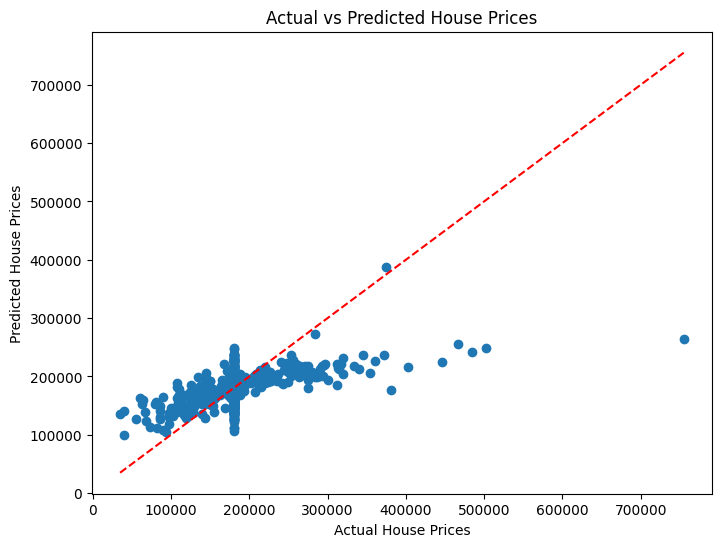

In [ ]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

# Labels and title
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices')

plt.show()

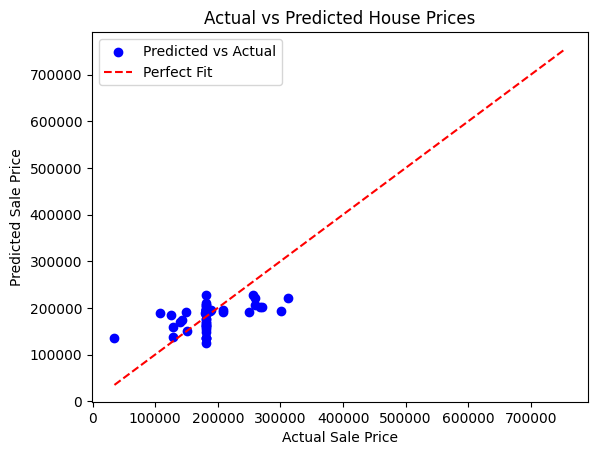

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test[:50], y_pred[:50], color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

## Explanation of the Graph
- Each dot represents one house prediction.
- The red dashed line represents perfect predictions.
- If points are close to the red line, the model predictions are accurate.
- Points far from the line represent prediction errors.

If most points are clustered near the line, it means the model is performing well.